# **Code for Synthetic Benchmark Results (section 3.1)**

- The training window is set to 60 days.

- To explore different scenarios, you can modify the baseline in **Code Section 6**.  
  Simply replace the current baseline with one of the other six scenarios.

- If you are using a Jupyter Notebook, run the full code once, then update only the baseline name in **Section 6** and re-run that section.  
  This allows you to easily simulate different behavioral regimes.

Training start=0, T_train=60


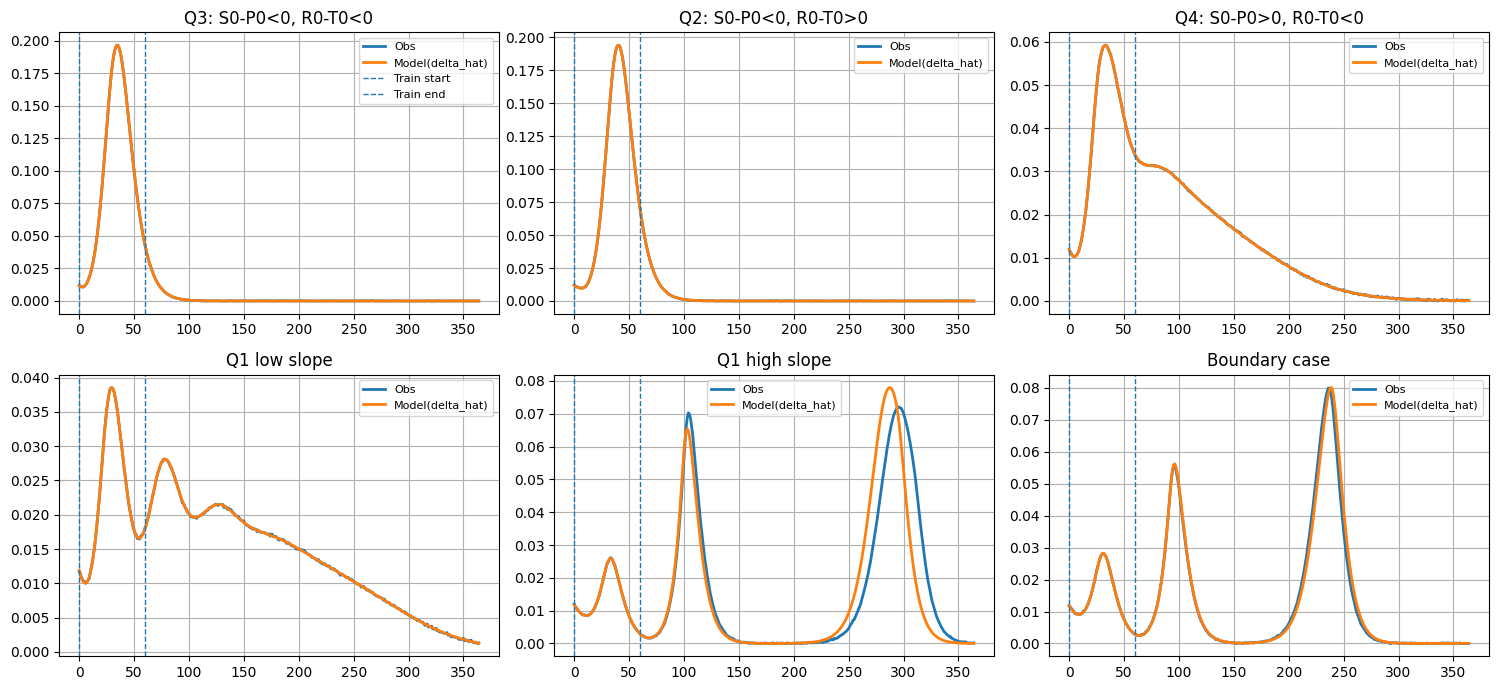


=== Scenario delta fit summary (order: [dRT1, dRT0, dSP1, dSP0]) ===

------------------------------
Q3: S0-P0<0, R0-T0<0
delta_true = [-0.5  -2.   -0.25 -1.4 ]
delta_hat  = [-0.8347 -0.7161 -0.5221 -0.6811]
||r||_2 (train, data) = 5.217203e-04
RMSE (train, data)    = 6.735380e-05
||delta_hat||_1       = 2.754050
Delta_err (RT+SP L1)  = 2.609530  (RT=1.618537, SP=0.990993)

------------------------------
Q2: S0-P0<0, R0-T0>0
delta_true = [-0.5   1.4  -0.25 -2.4 ]
delta_hat  = [-3.0000e-04 -3.9260e-01 -7.0000e-04 -3.4986e+00]
||r||_2 (train, data) = 6.230977e-04
RMSE (train, data)    = 8.044156e-05
||delta_hat||_1       = 3.892218
Delta_err (RT+SP L1)  = 3.640302  (RT=2.292343, SP=1.347960)

------------------------------
Q4: S0-P0>0, R0-T0<0
delta_true = [-0.5  -0.2  -0.25  0.75]
delta_hat  = [-0.5013 -0.2008 -0.2492  0.7509]
||r||_2 (train, data) = 6.423345e-04
RMSE (train, data)    = 8.292503e-05
||delta_hat||_1       = 1.702120
Delta_err (RT+SP L1)  = 0.003756  (RT=0.002072, SP=0.0

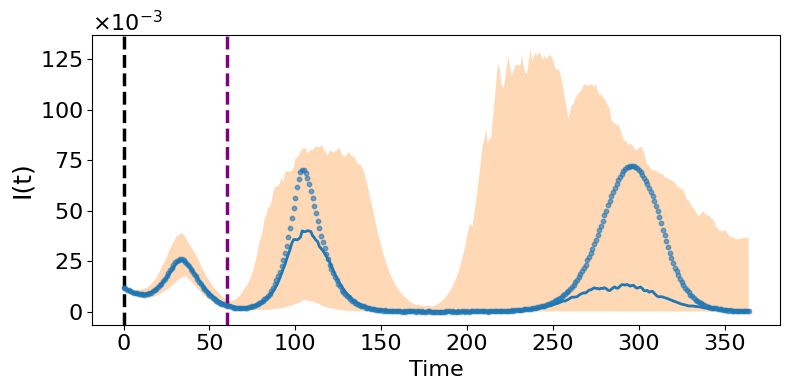


=== Monte Carlo delta summary (baseline: Q1 high slope) ===
Order: [delta_RT1, delta_RT0, delta_SP1, delta_SP0]
true  : [-0.5   1.5  -0.25  0.5 ]
median: [-0.5002  1.501  -0.25    0.4974]
2.5%  : [-0.533   1.4187 -0.3229  0.2389]
97.5% : [-0.4782  1.5893 -0.1648  0.6877]

=== MC param perturbation setting ===
Gaussian with hard clip: rel_std=0.1 (std=10%), clip_sigma=2.0 -> ±20% range

=== Monte Carlo error summary (baseline) ===
||r||_2 (train, data): median=0.000566988, 2.5%=0.000475401, 97.5%=0.000700169
Delta_err (RT+SP L1): median=0.110936, 2.5%=0.010021, 97.5%=0.561832
Delta_err_RT: median=0.0382434, 2.5%=0.003026, 97.5%=0.134624
Delta_err_SP: median=0.0713233, 2.5%=0.00348501, 97.5%=0.449136


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

# =========================================================
# SYNTHETIC (Eq.11) version: estimate delta gaps directly
# + CONSTRAINTS (softplus):
#   delta_RT1 <= 0, delta_SP1 <= 0 enforced by:
#     delta_RT1 = -softplus(u_RT1), delta_SP1 = -softplus(u_SP1)
# - NO A0/A1 matrices anywhere
# - Fit 4 "raw" params: [u_RT1, delta_RT0, u_SP1, delta_SP0]
#   but we report/plot with delta_hat = [dRT1, dRT0, dSP1, dSP0]
# =========================================================

# -----------------------------
# 1) ODE: SEIR + Replicator with Eq.(11) gap
# -----------------------------
def replicator_gap_eq11(x, theta, delta_vec):
    """
    Eq.(11) bracket term:
      gap(x,theta) =
        x*theta*delta_RT1 + x*(1-theta)*delta_RT0
      + (1-x)*theta*delta_SP1 + (1-x)*(1-theta)*delta_SP0
    """
    dRT1, dRT0, dSP1, dSP0 = delta_vec
    return (x*theta*dRT1
            + x*(1-theta)*dRT0
            + (1-x)*theta*dSP1
            + (1-x)*(1-theta)*dSP0)

def seir_replicator_ode_delta(t, y, pars, delta_vec, epsilon, beta0):
    S, E, I, R, x = y
    alpha, eta, mu = pars

    theta = np.clip(1.0 - epsilon*I, 0.0, 1.0)

    gap = replicator_gap_eq11(x, theta, delta_vec)
    dxdt = x*(1-x)*gap

    beta_t = beta0*(1-x)
    dSdt = -beta_t*S*I + mu*R
    dEdt =  beta_t*S*I - eta*E
    dIdt =  eta*E - alpha*I
    dRdt =  alpha*I - mu*R

    return np.array([dSdt, dEdt, dIdt, dRdt, dxdt], dtype=float)

def simulate_I_delta(time, y0, alpha, eta, mu, beta0, epsilon, delta_vec,
                     method="RK45"):
    def ode_wrap(t, y):
        return seir_replicator_ode_delta(t, y, (alpha, eta, mu), delta_vec, epsilon, beta0)

    t_span = (float(time[0]), float(time[-1]))
    sol = solve_ivp(
        ode_wrap, t_span, y0,
        method=method, t_eval=time,
        rtol=1e-6, atol=1e-9
    )
    if not sol.success:
        raise RuntimeError(f"ODE solve failed: {sol.message}")

    I = sol.y[2, :]
    sol_mat = sol.y.T
    return I, sol_mat

# -----------------------------
# 2) (NEW) softplus + raw -> constrained delta mapping
# -----------------------------
def softplus(z):
    # numerically stable softplus
    z = np.asarray(z, float)
    return np.log1p(np.exp(-np.abs(z))) + np.maximum(z, 0.0)

def raw_to_delta(u):
    """
    Optimization variables u = [u_RT1, dRT0, u_SP1, dSP0]
    Constrained delta = [dRT1, dRT0, dSP1, dSP0] where
      dRT1 = -softplus(u_RT1) <= 0
      dSP1 = -softplus(u_SP1) <= 0
      dRT0, dSP0 are free
    """
    u = np.asarray(u, float)
    dRT1 = -softplus(u[0])
    dRT0 = u[1]
    dSP1 = -softplus(u[2])
    dSP0 = u[3]
    return np.array([dRT1, dRT0, dSP1, dSP0], dtype=float)

# -----------------------------
# 3) Weighted LS for delta (raw 4 params)
# -----------------------------
def residuals_delta(p_raw, time, y0, I_obs,
                    alpha, eta, mu, beta0, epsilon,
                    gamma=1.01, lam=0.0, ode_method="RK45"):
    # (CHANGED) map raw -> constrained delta
    delta_hat = raw_to_delta(p_raw)

    I_model, _ = simulate_I_delta(
        time=time, y0=y0,
        alpha=alpha, eta=eta, mu=mu,
        beta0=beta0, epsilon=epsilon,
        delta_vec=delta_hat,
        method=ode_method
    )

    resid = I_model - I_obs
    T = len(resid)
    w = gamma ** (np.arange(T) - (T - 1))  # last is 1
    data_term = w * resid

    if lam is None or lam <= 0.0:
        return data_term

    # ridge on RAW variables (keeps optimization stable)
    ridge = np.sqrt(lam) * np.asarray(p_raw, float)
    return np.concatenate([data_term, ridge])

def fit_delta_least_squares(time, y0, I_obs,
                            alpha, eta, mu, beta0, epsilon,
                            p0=None, gamma=1.01, lam=0.0,
                            max_nfev=8000, ode_method="RK45"):
    if p0 is None:
        # p0 is RAW = [u_RT1, dRT0, u_SP1, dSP0]
        # u_RT1=0 -> dRT1=-softplus(0)≈-0.693 (negative start)
        p0 = np.array([0.0, 0.2, 0.0, 0.2], dtype=float)

    fun = lambda p: residuals_delta(
        p, time, y0, I_obs,
        alpha, eta, mu, beta0, epsilon,
        gamma=gamma, lam=lam, ode_method=ode_method
    )
    res = least_squares(fun, p0, method="trf", max_nfev=max_nfev)

    # (CHANGED) return constrained delta_hat for downstream code
    return res, raw_to_delta(res.x)

# -----------------------------
# (Metrics) residual L2 + delta L1 error (Delta_err)
# -----------------------------
def delta_err_L1(delta_hat, delta_true):
    """
    Delta_err = |dRT1hat-dRT1| + |dRT0hat-dRT0| + |dSP1hat-dSP1| + |dSP0hat-dSP0|
    Returns: (total, RT_part, SP_part)
    """
    delta_hat = np.asarray(delta_hat, float)
    delta_true = np.asarray(delta_true, float)
    err_RT = np.abs(delta_hat[0] - delta_true[0]) + np.abs(delta_hat[1] - delta_true[1])
    err_SP = np.abs(delta_hat[2] - delta_true[2]) + np.abs(delta_hat[3] - delta_true[3])
    return float(err_RT + err_SP), float(err_RT), float(err_SP)

def delta_L1_norm(delta):
    delta = np.asarray(delta, float)
    return float(np.sum(np.abs(delta)))

# -----------------------------
# 4) True params + scenarios (delta truth per scenario)
# -----------------------------
alpha_true   = 0.15
eta_true     = 0.1428
mu_true      = 0.0
beta0_true   = 0.7
epsilon_true = 20.0

y0_true = np.array([0.9372, 0.0083, 0.0119, 0.0424, 0.8754], dtype=float)

T_total = 365
t_full = np.arange(T_total)

train_start = 0
T_train     = 60
train_end   = train_start + T_train

# delta ordering: [delta_RT1, delta_RT0, delta_SP1, delta_SP0]
scenarios = [
    { "name": "Q3: S0-P0<0, R0-T0<0",
      "delta_true": np.array([-0.50, -2.00, -0.25, -1.40], dtype=float) },
    { "name": "Q2: S0-P0<0, R0-T0>0",
      "delta_true": np.array([-0.50,  1.40, -0.25, -2.40], dtype=float) },
    { "name": "Q4: S0-P0>0, R0-T0<0",
      "delta_true": np.array([-0.50, -0.20, -0.25,  0.75], dtype=float) },
    { "name": "Q1 low slope",
      "delta_true": np.array([-0.50,  0.20, -0.25,  1.00], dtype=float) },
    { "name": "Q1 high slope",
      "delta_true": np.array([-0.50,  1.50, -0.25,  0.50], dtype=float) },
    { "name": "Boundary case",
      "delta_true": np.array([-0.50,  1.20, -0.25,  0.60], dtype=float) }
]

sigma_I = 1e-4
gamma   = 1.01
lam     = 0.0
ode_method = "RK45"

# -----------------------------
# 5) Scenario fits (2x3 plot) — Obs + Model
#    + compute ||r||_2 and Delta_err (L1)
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

delta_hat_list = []
residual_norm_list = []
rmse_list = []
delta_err_list = []
delta_err_RT_list = []
delta_err_SP_list = []
delta_hat_L1_list = []

print(f"Training start={train_start}, T_train={T_train}")

for idx, sc in enumerate(scenarios):
    name = sc["name"]
    delta_true = sc["delta_true"]
    ax = axes[idx]

    # (A) generate synthetic obs with TRUE delta
    I_clean, sol_true = simulate_I_delta(
        time=t_full, y0=y0_true,
        alpha=alpha_true, eta=eta_true, mu=mu_true,
        beta0=beta0_true, epsilon=epsilon_true,
        delta_vec=delta_true,
        method=ode_method
    )
    I_obs_full = np.clip(I_clean + np.random.normal(0, sigma_I, size=I_clean.shape), 0, None)

    # (B) training window
    train_idx = np.arange(train_start, train_end)
    t_train = t_full[train_idx]
    t_train_rel = t_train - t_train[0]
    I_obs_train = I_obs_full[train_idx]

    y_start = sol_true[train_start, :]

    # (C) fit constrained delta via raw variables
    res, delta_hat = fit_delta_least_squares(
        time=t_train_rel, y0=y_start, I_obs=I_obs_train,
        alpha=alpha_true, eta=eta_true, mu=mu_true,
        beta0=beta0_true, epsilon=epsilon_true,
        p0=None, gamma=gamma, lam=lam,
        max_nfev=8000, ode_method=ode_method
    )

    delta_hat_list.append((name, delta_true, delta_hat))

    # residual metrics on TRAIN (data only)
    T = len(I_obs_train)
    r = res.fun
    r_data = r[:T]
    residual_norm = np.linalg.norm(r_data, 2)   # ||r||_2
    rmse = np.sqrt(np.mean(r_data**2))

    residual_norm_list.append(residual_norm)
    rmse_list.append(rmse)

    # delta L1 metrics
    Delta_err, Delta_err_RT, Delta_err_SP = delta_err_L1(delta_hat, delta_true)
    delta_err_list.append(Delta_err)
    delta_err_RT_list.append(Delta_err_RT)
    delta_err_SP_list.append(Delta_err_SP)
    delta_hat_L1_list.append(delta_L1_norm(delta_hat))

    # (D) forward with fitted constrained delta_hat
    I_model_hat, _ = simulate_I_delta(
        time=t_full, y0=y0_true,
        alpha=alpha_true, eta=eta_true, mu=mu_true,
        beta0=beta0_true, epsilon=epsilon_true,
        delta_vec=delta_hat,
        method=ode_method
    )

    # plot
    ax.plot(t_full, I_obs_full, label="Obs", lw=2)
    ax.plot(t_full[t_full >= train_start], I_model_hat[t_full >= train_start],
            label="Model(delta_hat)", lw=2)

    ax.axvline(train_start, linestyle="--", linewidth=1,
               label="Train start" if idx == 0 else None)
    ax.axvline(train_end, linestyle="--", linewidth=1,
               label="Train end" if idx == 0 else None)

    ax.set_title(name)
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"scenarios_deltaEq11_Tstart{train_start}_Ttrain{T_train}.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("\n=== Scenario delta fit summary (order: [dRT1, dRT0, dSP1, dSP0]) ===")
for (name, dtrue, dhat), resL2, rmse, Derr, DerrRT, DerrSP, dhatL1 in zip(
        delta_hat_list, residual_norm_list, rmse_list,
        delta_err_list, delta_err_RT_list, delta_err_SP_list, delta_hat_L1_list):
    print("\n------------------------------")
    print(name)
    print("delta_true =", np.round(dtrue, 4))
    print("delta_hat  =", np.round(dhat, 4))
    print(f"||r||_2 (train, data) = {resL2:.6e}")
    print(f"RMSE (train, data)    = {rmse:.6e}")
    print(f"||delta_hat||_1       = {dhatL1:.6f}")
    print(f"Delta_err (RT+SP L1)  = {Derr:.6f}  (RT={DerrRT:.6f}, SP={DerrSP:.6f})")

# -----------------------------
# 6) Monte Carlo CI band (baseline scenario)
#    + compute ||r||_2(train) and Delta_err per MC sample
# -----------------------------
def sample_pos_gauss_clip(mean, rel_std=0.1, clip_sigma=2.0, minval=1e-8):
    mean = float(mean)
    std = rel_std * mean
    if std <= 0.0:
        return max(mean, minval)

    low  = mean - clip_sigma * std
    high = mean + clip_sigma * std

    x = np.random.normal(mean, std)
    x = float(np.clip(x, low, high))
    return max(x, minval)

def sample_disease_params_clip20(alpha_mean, eta_mean, mu_mean, beta0_mean, eps_mean,
                                 rel_std=0.1, clip_sigma=2.0):
    alpha_s = sample_pos_gauss_clip(alpha_mean, rel_std=rel_std, clip_sigma=clip_sigma, minval=1e-5)
    eta_s   = sample_pos_gauss_clip(eta_mean,   rel_std=rel_std, clip_sigma=clip_sigma, minval=1e-5)

    mu_s = float(mu_mean)
    mu_s = max(mu_s, 0.0)

    beta0_s = sample_pos_gauss_clip(beta0_mean, rel_std=rel_std, clip_sigma=clip_sigma, minval=1e-5)
    eps_s   = sample_pos_gauss_clip(eps_mean,   rel_std=rel_std, clip_sigma=clip_sigma, minval=1e-5)

    return alpha_s, eta_s, mu_s, beta0_s, eps_s

def monte_carlo_for_scenario(delta_true,
                             n_samples=200,
                             train_start=0,
                             T_train=30,
                             sigma_I=1e-4,
                             gamma=1.01,
                             lam=0.0,
                             ode_method="RK45",
                             rel_std=0.1,
                             clip_sigma=2.0):
    I_traj_list = []
    DELTA_list  = []

    RESL2_list = []
    DERR_list = []
    DERR_RT_list = []
    DERR_SP_list = []

    train_end = train_start + T_train

    for k in range(n_samples):
        if (k + 1) % 25 == 0:
            print(f"{k+1}/{n_samples} completed")

        # (0) disease param sampling: ±20% hard clip
        alpha_s, eta_s, mu_s, beta0_s, eps_s = sample_disease_params_clip20(
            alpha_true, eta_true, mu_true, beta0_true, epsilon_true,
            rel_std=rel_std, clip_sigma=clip_sigma
        )

        # (1) generate synthetic obs (TRUE delta)
        I_clean, sol_true = simulate_I_delta(
            time=t_full, y0=y0_true,
            alpha=alpha_s, eta=eta_s, mu=mu_s,
            beta0=beta0_s, epsilon=eps_s,
            delta_vec=delta_true,
            method=ode_method
        )
        I_obs_full = np.clip(I_clean + np.random.normal(0, sigma_I, size=I_clean.shape), 0, None)

        # (2) training window
        train_idx = np.arange(train_start, train_end)
        t_train = t_full[train_idx]
        t_train_rel = t_train - t_train[0]
        I_obs_train = I_obs_full[train_idx]
        y_start = sol_true[train_start, :]

        # (3) fit constrained delta on training
        res, delta_hat = fit_delta_least_squares(
            time=t_train_rel, y0=y_start, I_obs=I_obs_train,
            alpha=alpha_s, eta=eta_s, mu=mu_s,
            beta0=beta0_s, epsilon=eps_s,
            p0=None, gamma=gamma, lam=lam,
            max_nfev=6000, ode_method=ode_method
        )

        # metrics for this MC sample
        T = len(I_obs_train)
        r = res.fun
        r_data = r[:T]
        RESL2_list.append(float(np.linalg.norm(r_data, 2)))

        Derr, DerrRT, DerrSP = delta_err_L1(delta_hat, delta_true)
        DERR_list.append(Derr)
        DERR_RT_list.append(DerrRT)
        DERR_SP_list.append(DerrSP)

        # (4) forward prediction with delta_hat
        I_hat, _ = simulate_I_delta(
            time=t_full, y0=y0_true,
            alpha=alpha_s, eta=eta_s, mu=mu_s,
            beta0=beta0_s, epsilon=eps_s,
            delta_vec=delta_hat,
            method=ode_method
        )

        I_traj_list.append(I_hat)
        DELTA_list.append(delta_hat)

    return (np.array(I_traj_list),
            np.array(DELTA_list),
            np.array(RESL2_list),
            np.array(DERR_list),
            np.array(DERR_RT_list),
            np.array(DERR_SP_list))

# baseline: Q1 high slope
baseline = [sc for sc in scenarios if sc["name"] == "Q1 high slope"][0]
delta_true_baseline = baseline["delta_true"]

n_samples = 200

# (±20% hard clip)
rel_std = 0.10
clip_sigma = 2.0

I_traj_arr, DELTA_arr, RESL2_arr, DERR_arr, DERR_RT_arr, DERR_SP_arr = monte_carlo_for_scenario(
    delta_true=delta_true_baseline,
    n_samples=n_samples,
    train_start=train_start,
    T_train=T_train,
    sigma_I=sigma_I,
    gamma=gamma,
    lam=lam,
    ode_method=ode_method,
    rel_std=rel_std,
    clip_sigma=clip_sigma
)

# make ONE "actual observation" series for overlay (same truth + noise)
I_clean_b, _ = simulate_I_delta(
    time=t_full, y0=y0_true,
    alpha=alpha_true, eta=eta_true, mu=mu_true,
    beta0=beta0_true, epsilon=epsilon_true,
    delta_vec=delta_true_baseline,
    method=ode_method
)
I_obs_full_baseline = np.clip(I_clean_b + np.random.normal(0, sigma_I, size=I_clean_b.shape), 0, None)

# bands
I_lower  = np.percentile(I_traj_arr, 2.5, axis=0)
I_upper  = np.percentile(I_traj_arr, 97.5, axis=0)
I_median = np.percentile(I_traj_arr, 50, axis=0)

plt.figure(figsize=(8, 4))
ax = plt.gca()

# ----- plots -----
ax.scatter(t_full, I_obs_full_baseline, s=10, alpha=0.6, label="Obs", zorder=3)
ax.fill_between(t_full, I_lower, I_upper, alpha=0.3, label="95% band", zorder=2)
ax.plot(t_full, I_median, linewidth=2, label="Median prediction", zorder=4)

train_end = train_start + T_train
ax.axvline(train_start, linestyle="--", linewidth=2.5, color="black", label="Train start")
ax.axvline(train_end,   linestyle="--", linewidth=2.5, color="purple", label="Train end")

# ----- NO GRID -----
ax.grid(False)

# ----- Font sizes -----
xlabel_fs = 16
ylabel_fs = 18
tick_fs   = 16
legend_fs = 12

ax.set_xlabel("Time", fontsize=xlabel_fs)
ax.set_ylabel("I(t)", fontsize=ylabel_fs)
ax.tick_params(axis='both', labelsize=tick_fs)

# ----- y-axis scientific notation  -----
ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, -3), useMathText=True)
ax.yaxis.get_offset_text().set_size(tick_fs)  # ×10^-3

# ----- legend -----
#ax.legend(fontsize=legend_fs, frameon=True)

plt.tight_layout()
plt.savefig("CI_Q1_high_slope_deltaEq11_clip20.png", dpi=300, bbox_inches="tight")
plt.show()

# delta summary
delta_median = np.percentile(DELTA_arr, 50, axis=0)
delta_lo     = np.percentile(DELTA_arr, 2.5, axis=0)
delta_hi     = np.percentile(DELTA_arr, 97.5, axis=0)

print("\n=== Monte Carlo delta summary (baseline: Q1 high slope) ===")
print("Order: [delta_RT1, delta_RT0, delta_SP1, delta_SP0]")
print("true  :", np.round(delta_true_baseline, 4))
print("median:", np.round(delta_median, 4))
print("2.5%  :", np.round(delta_lo, 4))
print("97.5% :", np.round(delta_hi, 4))

print("\n=== MC param perturbation setting ===")
print(f"Gaussian with hard clip: rel_std={rel_std} (std=10%), clip_sigma={clip_sigma} -> ±{clip_sigma*rel_std*100:.0f}% range")

# MC error summaries
def summarize(arr, name):
    med = np.percentile(arr, 50)
    lo  = np.percentile(arr, 2.5)
    hi  = np.percentile(arr, 97.5)
    print(f"{name}: median={med:.6g}, 2.5%={lo:.6g}, 97.5%={hi:.6g}")

print("\n=== Monte Carlo error summary (baseline) ===")
summarize(RESL2_arr, "||r||_2 (train, data)")
summarize(DERR_arr,  "Delta_err (RT+SP L1)")
summarize(DERR_RT_arr, "Delta_err_RT")
summarize(DERR_SP_arr, "Delta_err_SP")